# This Notebook Aims to Fit a Multiple Linear Regression Model and Study It

## Importing

In [1]:
from pathlib import Path
import sys
root= Path.cwd().parent
sys.path.append(str(root))
from src.regression import normal_equation, RSE, R_Square, linear_predict, F_statistic, p_values, mallows_cp, aic, bic, adjusted_r2, stepwise_selection
from src.graph import residuals_vs_predicted_values, residuals_histogram
import pandas as pd

In [2]:
training_data = pd.read_csv("../data/processed/training_data.csv")
testing_data = pd.read_csv("../data/processed/testing_data.csv")

## Fitting the Model using the Least Squares Estimates

The first element in the parameters array is the bias

In [3]:
X= pd.concat([training_data.iloc[:, 0:3], training_data.iloc[:, 4:]], axis=1 )
y= training_data.iloc[:, 3]
normal_params = normal_equation(X, y)

In [4]:
normal_params

array([ 1.38670053e-02, -5.09131817e-01, -5.49885081e-01,  1.18269073e-01,
        8.91322502e-02,  1.11041632e-01,  5.73634147e-02, -7.12884431e-02,
        1.11670763e-01, -6.88155736e-01,  6.66333750e-01,  6.31719517e-01,
        8.78346504e-02, -2.04040947e-01,  7.57294208e-04,  1.16772655e+00])

## Assessing the Accuracy

Make the predictions on the seen data (training set) and unseen data (testing set)

In [5]:
testing_X = pd.concat([testing_data.iloc[:, 0:3], testing_data.iloc[:, 4:]], axis=1 )
test_predictions = linear_predict(testing_X, normal_params)
train_predictions = linear_predict(X, normal_params)

Seeing the accuracy

In [6]:
testing_targets = testing_data.iloc[:, 3]
training_targets = y

In [7]:
test_RSE = RSE(testing_targets, test_predictions, len(normal_params)-1)
train_RSE = RSE(training_targets, train_predictions, len(normal_params)-1)
test_R_Squared = R_Square(testing_targets, test_predictions)
train_R_Squared = R_Square(training_targets, train_predictions)

In [8]:
print("------------RSE------------")
print(f"Training RSE is: {train_RSE}")
print(f"Testing RSE is: {test_RSE}")
print("------------R**2------------")
print(f"Training R**2 is: {train_R_Squared*100}%")
print(f"Testing R**2 is: {test_R_Squared*100}%")

------------RSE------------
Training RSE is: 0.5994974901273423
Testing RSE is: 0.6188285886566696
------------R**2------------
Training R**2 is: 62.89891931486471%
Testing R**2 is: 65.1401133816348%


## Hypothesis Testing using F-Statistic

We are testing
H0 (the null hypothesis): all coefficient are equal to 0 (the predictors don't have any linear relationship with the response)
Ha (the alternative hypothesis): at least one coefficient isn't equal to 0

In [9]:
F_stat, p_val = F_statistic(testing_targets,test_predictions, len(normal_params)-1)

In [10]:
print(f'The F-statistic is equal to: {F_stat}\nWe can refuse H0 with significance level of {p_val*100}% (very small)')

The F-statistic is equal to: 512.252854133243
We can refuse H0 with significance level of 0.0% (very small)


## Calculating the p-values

In [11]:
p_vals = p_values(X, training_targets, train_predictions, normal_params)

In [12]:
predictors = X.columns
print("p-value of the intercept= ", p_vals[0])
for i, predictor in enumerate(predictors):
    print(f'p-value of the predictor {predictor}= {p_vals[i+1]}')

p-value of the intercept=  0.4224663164982646
p-value of the predictor longitude= 5.8653155944755e-107
p-value of the predictor latitude= 4.158819594592479e-121
p-value of the predictor housing_median_age= 2.70969486478718e-107
p-value of the predictor bedrooms_per_room= 9.615359166749719e-12
p-value of the predictor population_per_household= 2.3570741500512296e-27
p-value of the predictor rooms_per_household= 1.1782830184273059e-12
p-value of the predictor log_total_rooms= 0.15051867536857128
p-value of the predictor log_total_bedrooms= 0.026532905503756622
p-value of the predictor log_population= 0.0
p-value of the predictor log_households= 1.0383631784176709e-70
p-value of the predictor log_median_income= 0.0
p-value of the predictor <1h ocean= 1.5317423322373482e-05
p-value of the predictor inland= 2.0706831726503324e-17
p-value of the predictor near ocean= 0.9745418946758698
p-value of the predictor island= 1.4398566221698238e-05


## Plotting the Residuals vs Predicted Values

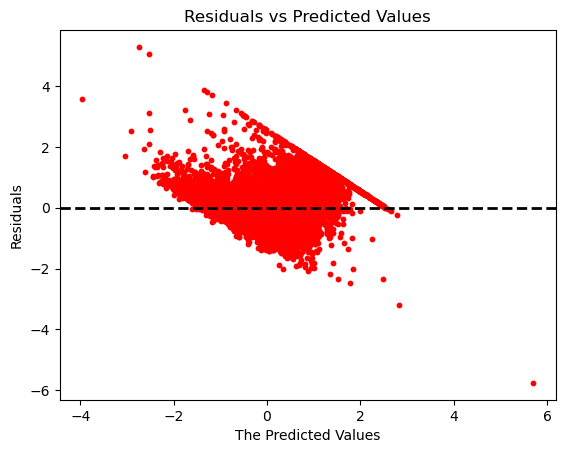

In [13]:
residuals_vs_predicted_values(training_targets, train_predictions)

## Plotting the Residuals Histogram (to check normality)

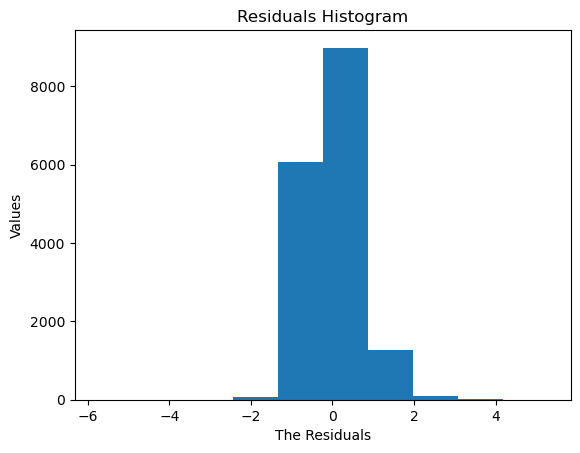

In [14]:
residuals_histogram(training_targets, train_predictions)

## Subset Selection

Select a subset of predictors (Remove predictors that increase complexity without adding much power to the model), using different metrics of evaluation

In [15]:
dataset_X = pd.concat([X, testing_X], ignore_index=True)
dataset_targets = pd.concat([training_targets, testing_targets], ignore_index=True).to_numpy()

In [16]:
len(dataset_X.columns)

15

In [17]:
dataset_X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'bedrooms_per_room',
       'population_per_household', 'rooms_per_household', 'log_total_rooms',
       'log_total_bedrooms', 'log_population', 'log_households',
       'log_median_income', '<1h ocean', 'inland', 'near ocean', 'island'],
      dtype='object')

### 1- Mallow's Cp

In [18]:
mallows_cp_params, mallows_cp_value, mallows_cp_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), mallows_cp)

Adding the predictor log_median_income resulting in mallows_cp=0.5512413556266954
Adding the predictor inland resulting in mallows_cp=0.44432719357430167
Adding the predictor housing_median_age resulting in mallows_cp=0.43177698822342275
Adding the predictor bedrooms_per_room resulting in mallows_cp=0.4214442827414842
Adding the predictor <1h ocean resulting in mallows_cp=0.4179357333549828
Adding the predictor log_total_bedrooms resulting in mallows_cp=0.4146888962561142
Adding the predictor log_population resulting in mallows_cp=0.3836291169285782
Adding the predictor log_households resulting in mallows_cp=0.3756918301905746
Adding the predictor population_per_household resulting in mallows_cp=0.3739798891664584
Adding the predictor rooms_per_household resulting in mallows_cp=0.3730215862734747
Adding the predictor latitude resulting in mallows_cp=0.3726204299322087
Adding the predictor longitude resulting in mallows_cp=0.3596780475101015
Removing the predictor log_total_bedrooms res

In [19]:
len(mallows_cp_predictors)

13

In [20]:
mallows_cp_predictors

['log_median_income',
 'inland',
 'housing_median_age',
 'bedrooms_per_room',
 '<1h ocean',
 'log_population',
 'log_households',
 'population_per_household',
 'rooms_per_household',
 'latitude',
 'longitude',
 'island',
 'near ocean']

### 2- Adjusted R**2

In [21]:
adjusted_r2_params, adjusted_r2_value, adjusted_r2_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), adjusted_r2, True)

Adding the predictor log_median_income resulting in adjusted_r2=0.4487586443733109
Adding the predictor inland resulting in adjusted_r2=0.5556943328630648
Adding the predictor housing_median_age resulting in adjusted_r2=0.5682648465782705
Adding the predictor bedrooms_per_room resulting in adjusted_r2=0.5786169647927077
Adding the predictor <1h ocean resulting in adjusted_r2=0.5821452462484622
Adding the predictor log_total_bedrooms resulting in adjusted_r2=0.5854115369955875
Adding the predictor log_population resulting in adjusted_r2=0.6164823707543465
Adding the predictor log_households resulting in adjusted_r2=0.6244355414765645
Adding the predictor population_per_household resulting in adjusted_r2=0.6261650081172214
Adding the predictor rooms_per_household resulting in adjusted_r2=0.6271409975938578
Adding the predictor latitude resulting in adjusted_r2=0.6275600157965764
Adding the predictor longitude resulting in adjusted_r2=0.6405135392664564
Removing the predictor log_total_be

In [22]:
len(adjusted_r2_predictors)

13

### 3- AIC

In [23]:
aic_params, aic_value, aic_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), aic)

Adding the predictor log_median_income resulting in aic=0.5512413556266954
Adding the predictor inland resulting in aic=0.44432719357430167
Adding the predictor housing_median_age resulting in aic=0.43177698822342275
Adding the predictor bedrooms_per_room resulting in aic=0.4214442827414842
Adding the predictor <1h ocean resulting in aic=0.4179357333549828
Adding the predictor log_total_bedrooms resulting in aic=0.4146888962561142
Adding the predictor log_population resulting in aic=0.3836291169285782
Adding the predictor log_households resulting in aic=0.3756918301905746
Adding the predictor population_per_household resulting in aic=0.3739798891664584
Adding the predictor rooms_per_household resulting in aic=0.3730215862734747
Adding the predictor latitude resulting in aic=0.3726204299322087
Adding the predictor longitude resulting in aic=0.3596780475101015
Removing the predictor log_total_bedrooms resulting in aic=0.3596444160211207
Adding the predictor island resulting in aic=0.3593

In [24]:
len(aic_predictors)

13

In [25]:
aic_predictors

['log_median_income',
 'inland',
 'housing_median_age',
 'bedrooms_per_room',
 '<1h ocean',
 'log_population',
 'log_households',
 'population_per_household',
 'rooms_per_household',
 'latitude',
 'longitude',
 'island',
 'near ocean']

### 4- BIC

In [26]:
bic_params, bic_value, bic_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), bic)

Adding the predictor log_median_income resulting in bic=0.5514532787158702
Adding the predictor inland resulting in bic=0.44466881754193927
Adding the predictor housing_median_age resulting in bic=0.43227492608576523
Adding the predictor bedrooms_per_room resulting in bic=0.42209228052782943
Adding the predictor <1h ocean resulting in bic=0.41873894840169096
Adding the predictor log_total_bedrooms resulting in bic=0.4156452200179581
Adding the predictor log_population resulting in bic=0.38466121236080947
Adding the predictor log_households resulting in bic=0.3768469072459829
Adding the predictor population_per_household resulting in bic=0.37527336685933305
Adding the predictor rooms_per_household resulting in bic=0.37445503154767285
Removing the predictor log_total_bedrooms resulting in bic=0.37441254938636126
Adding the predictor latitude resulting in bic=0.37415216214032493
Adding the predictor longitude resulting in bic=0.36116458591632183
Removing the predictor <1h ocean resulting 

In [27]:
len(bic_predictors)

11